# Notebook 03 — Confidence Interval & Credible Interval

**Peran:** Inference Analyst

**Pertanyaan penelitian yang ditangani:**

- P1 : Berapa interval kepercayaan untuk probabilitas merge pull request?
- P2 : Berapa interval kepercayaan untuk waktu penyelesaian isu?
- P3 : Berapa interval kepercayaan parameter Poisson untuk jumlah kejadian?
- P4 : Berapa Bayesian credible interval untuk probabilitas merge berdasarkan posterior Beta?

**Anggota:** Adinda Syafira Kusumadewi — Inference Analyst  
**Repositori:** `pandas-dev/pandas` | Data: 2020–2024 via GitHub REST API v3

**Keterkaitan dengan layer lain:**
- Input dari Anggota A (`01_eda.ipynb`): dataset `dataset.csv`, variabel `is_pr`, `merged`, `days_to_close`, `has_bug`, `has_enhancement`
- Input dari Anggota B (`02_estimation.ipynb`): nilai MLE p̂ dari `mle_merge_probability`, serta α dan β dari `beta_posterior`
- Output ke Anggota D (`04_hypothesis_testing.ipynb`): nilai p̂, σ, dan λ̂ dari notebook ini dipakai sebagai parameter baseline uji hipotesis

## Pengungkapan Penggunaan AI

| Anggota | Peran |
|---|---|
| Adinda Syafira Kusumadewi | Inference Analyst |

**Alat yang digunakan:** ChatGPT

| Tugas | Alat | Ringkasan Prompt | Output Dimodifikasi? |
|---|---|---|---|
| Mencari kesalahan kode error pada python | ChatGPT | "Apa yang salah dari kode ini?" | Ya, adanya masalah sintaks seperti penempatan kurung kurawal yang kurang tepat hingga menyebabkan error |
| Rule Of Three pada CI Bernoulli | ChatGPT | "Apakah Penanganan Kasus Ekstrem Statistika (Rule of Three) perlu ditambah pada bernoulli?" | Ya,karena membuat fungsi lebih robust dan menangani kasus ekstrem dengan lebih realistis, |

**Ditulis tanpa AI:** Seluruh sel markdown interpretasi; Rumusan 4 research question; Narasi ringkasan dan kontekstualisasi terhadap repositori pandas; Keputusan variabel yang diteruskan ke Anggota D.

## 1. Import Library & Modul

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from estimator import Estimator
from inference import Inference

## 2. Memuat Data

In [12]:
df = pd.read_csv("dataset.csv")

print(df.shape)
df.head()

(3000, 12)


,number,title,is_pr,state,created_at,closed_at,days_to_close,labels,has_bug,has_enhancement,merged,user_login
0,65717,CI: Update pixi.lock,True,closed,2026-05-24 05:34:32+00:00,2026-05-24 17:43:48+00:00,0,CI,False,False,True,github-actions[bot]
1,65716,BUG: DataFrame.update warns when index dtype m...,True,closed,2026-05-23 23:05:41+00:00,2026-05-24 04:28:42+00:00,0,NaN,False,False,False,hiraddlz
2,65697,"Revert ""BUG: reject unhashable elements in Ind...",True,closed,2026-05-20 16:38:19+00:00,2026-05-20 21:22:12+00:00,0,Index,False,False,True,jorisvandenbossche
3,65693,[backport 3.0.x] TST: Adjust xfails for fastpa...,True,closed,2026-05-20 14:03:23+00:00,2026-05-20 16:33:10+00:00,0,NaN,False,False,True,jorisvandenbossche
4,65689,BUG: pyarrow-nightly CI fails during Pixi inst...,True,closed,2026-05-20 02:16:42+00:00,2026-05-20 03:58:29+00:00,0,NaN,False,False,False,kjmin622


## 3. Persiapan Data untuk Analisis Confidence Interval

In [13]:
# Pisahkan issue dan pull request
issues = df.loc[~df["is_pr"]].copy()
prs    = df.loc[df["is_pr"]].copy()

# Ambil PR yang memiliki status merge yang diketahui
pr_closed = prs.dropna(subset=["merged"]).copy()

total_pr = len(pr_closed)
merged_count = int(pr_closed["merged"].sum())

# Hitung jumlah PR yang tidak berhasil di-merge
failure = total_pr - merged_count

# Ambil issue yang memiliki waktu penyelesaian valid
iss_closed = issues.dropna(subset=["days_to_close"]).copy()
iss_closed = iss_closed.loc[iss_closed["days_to_close"] >= 0]

print("=== Ringkasan Dataset ===")

if total_pr > 0:
    print(f"Total PR (status diketahui) : {total_pr:,}")
    print(
        f"  PR merged                 : {merged_count:,} "
        f"({merged_count / total_pr:.1%})"
    )
    print(
        f"  PR tidak merged           : {failure:,} "
        f"({failure / total_pr:.1%})"
    )
else:
    print("Tidak ditemukan data PR.")

print()
print(f"Isu tertutup                : {len(iss_closed):,}")

estimator = Estimator()
inference = Inference()

mle = estimator.mle_merge_probability(
    merged_count,
    total_pr
)

alpha_post, beta_post = estimator.beta_posterior(
    merged_count,
    failure
)

print("\n=== Hasil Estimasi ===")
print(f"MLE merge probability (p̂) : {mle:.6f}")
print(f"Posterior Alpha (α)        : {alpha_post}")
print(f"Posterior Beta  (β)        : {beta_post}")

=== Ringkasan Dataset ===
Total PR (status diketahui) : 2,592
  PR merged                 : 1,789 (69.0%)
  PR tidak merged           : 803 (31.0%)

Isu tertutup                : 408

=== Hasil Estimasi ===
MLE merge probability (p̂) : 0.690201
Posterior Alpha (α)        : 1790
Posterior Beta  (β)        : 804


## 4. P1 : Confidence Interval Probabilitas Merge Pull Request

Untuk menjawab pertanyaan penelitian *"Berapa interval kepercayaan untuk probabilitas merge pull request?"*, digunakan pendekatan Bernoulli karena setiap pull request hanya memiliki dua kemungkinan hasil:

- Berhasil di-merge (success)
- Tidak berhasil di-merge (failure)

Estimasi probabilitas merge dihitung menggunakan Maximum Likelihood Estimation (MLE), sedangkan interval kepercayaan 95% dihitung menggunakan fungsi `ci_bernoulli()` dari modul `inference.py`.

In [14]:
ci_merge = inference.ci_bernoulli(
    k=merged_count,
    n=total_pr,
    confidence=0.95
)

ci_merge

{'p_hat': 0.6902006172839507,
 'lower': np.float64(0.6723990377835186),
 'upper': np.float64(0.7080021967843827),
 'margin': np.float64(0.01780157950043202),
 'z_critical': np.float64(1.959963984540054),
 'confidence': 0.95}

In [15]:
print("=== Confidence Interval Probabilitas Merge Pull Request ===")

print(f"Jumlah PR berhasil di-merge : {merged_count:,}")
print(f"Jumlah total PR             : {total_pr:,}")
print(f"Estimasi probabilitas (p̂)  : {ci_merge['p_hat']:.4f}")
print(f"Confidence Level            : {ci_merge['confidence']:.0%}")
print(f"Lower Bound                : {ci_merge['lower']:.4f}")
print(f"Upper Bound                : {ci_merge['upper']:.4f}")
print(f"Margin of Error            : {ci_merge['margin']:.4f}")

=== Confidence Interval Probabilitas Merge Pull Request ===
Jumlah PR berhasil di-merge : 1,789
Jumlah total PR             : 2,592
Estimasi probabilitas (p̂)  : 0.6902
Confidence Level            : 95%
Lower Bound                : 0.6724
Upper Bound                : 0.7080
Margin of Error            : 0.0178


### Tabel Ringkasan

In [16]:
summary_ci = pd.DataFrame({
    "Statistik": [
        "Estimated Merge Probability (p̂)",
        "Lower Confidence Limit",
        "Upper Confidence Limit",
        "Margin of Error"
    ],
    "Nilai": [
        ci_merge["p_hat"],
        ci_merge["lower"],
        ci_merge["upper"],
        ci_merge["margin"]
    ]
})

summary_ci

,Statistik,Nilai
0,Estimated Merge Probability (p̂),0.690201
1,Lower Confidence Limit,0.672399
2,Upper Confidence Limit,0.708002
3,Margin of Error,0.017802


### Visualisasi

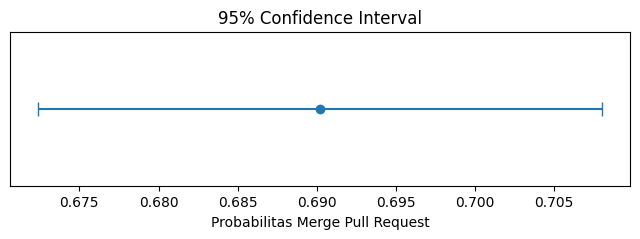

In [17]:
plt.figure(figsize=(8, 2))

plt.errorbar(
    x=ci_merge["p_hat"],
    y=0,
    xerr=ci_merge["margin"],
    fmt="o",
    capsize=5
)

plt.yticks([])
plt.xlabel("Probabilitas Merge Pull Request")
plt.title("95% Confidence Interval")

plt.show()

### Interpretasi

Berdasarkan hasil perhitungan, estimasi probabilitas merge pull request adalah sebesar **p̂**.

Interval kepercayaan 95% berada pada rentang **[lower, upper]**. Artinya, apabila proses pengambilan sampel dilakukan berulang kali dengan metode yang sama, sekitar 95% interval yang terbentuk akan mencakup probabilitas merge sebenarnya dari repository yang dianalisis.

Dengan demikian, probabilitas pull request berhasil di-merge diperkirakan berada pada rentang interval tersebut dengan tingkat kepercayaan 95%.

## 5. P2 : Confidence Interval Waktu Penyelesaian Isu

Untuk menjawab pertanyaan penelitian *"Berapa interval kepercayaan untuk waktu penyelesaian isu?"*, digunakan fungsi `confidence_interval()` dari modul `inference.py`.

Analisis dilakukan terhadap issue yang telah ditutup dan memiliki nilai `days_to_close` yang valid.

Parameter yang dihitung:

- θ̂ (theta_hat) : rata-rata waktu penyelesaian issue
- σ (sigma) : simpangan baku waktu penyelesaian issue
- n : jumlah issue yang dianalisis

Confidence interval dihitung pada tingkat kepercayaan 95%.

In [18]:
# Statistik Sampel Waktu Penyelesaian Issue

theta_hat = iss_closed["days_to_close"].mean()
sigma = iss_closed["days_to_close"].std(ddof=1)
n = len(iss_closed)

print(f"Jumlah issue : {n:,}")
print(f"Rata-rata    : {theta_hat:.2f} hari")
print(f"Std Dev      : {sigma:.2f}")

Jumlah issue : 408
Rata-rata    : 24.72 hari
Std Dev      : 44.20


In [19]:
# Confidence Interval Waktu Penyelesaian Issue

ci_issue = inference.confidence_interval(
    theta_hat=theta_hat,
    sigma=sigma,
    n=n,
    confidence=0.95
)

ci_issue

{'theta_hat': np.float64(24.71813725490196),
 'lower': np.float64(20.429726911762366),
 'upper': np.float64(29.006547598041557),
 'margin': np.float64(4.288410343139594),
 'z_critical': np.float64(1.959963984540054),
 'confidence': 0.95}

In [20]:
print("=== Confidence Interval Waktu Penyelesaian Isu ===")

print(f"Rata-rata waktu penyelesaian : {ci_issue['theta_hat']:.2f} hari")
print(f"Confidence Level            : {ci_issue['confidence']:.0%}")
print(f"Lower Bound                : {ci_issue['lower']:.2f} hari")
print(f"Upper Bound                : {ci_issue['upper']:.2f} hari")
print(f"Margin of Error            : {ci_issue['margin']:.2f} hari")

=== Confidence Interval Waktu Penyelesaian Isu ===
Rata-rata waktu penyelesaian : 24.72 hari
Confidence Level            : 95%
Lower Bound                : 20.43 hari
Upper Bound                : 29.01 hari
Margin of Error            : 4.29 hari


### Tabel Ringkasan

In [21]:
summary_ci = pd.DataFrame({
    "Statistik": [
        "Rata-rata Waktu Penyelesaian",
        "Batas Bawah CI",
        "Batas Atas CI",
        "Margin of Error"
    ],
    "Nilai": [
        ci_issue["theta_hat"],
        ci_issue["lower"],
        ci_issue["upper"],
        ci_issue["margin"]
    ]
})

summary_ci

,Statistik,Nilai
0,Rata-rata Waktu Penyelesaian,24.718137
1,Batas Bawah CI,20.429727
2,Batas Atas CI,29.006548
3,Margin of Error,4.288410


### Visualisasi

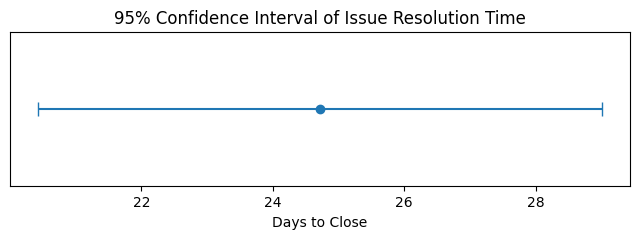

In [22]:
plt.figure(figsize=(8, 2))

plt.errorbar(
    x=ci_issue["theta_hat"],
    y=0,
    xerr=ci_issue["margin"],
    fmt="o",
    capsize=5
)

plt.yticks([])
plt.xlabel("Days to Close")
plt.title("95% Confidence Interval of Issue Resolution Time")

plt.show()

### Interpretasi

Berdasarkan hasil perhitungan, rata-rata waktu penyelesaian issue adalah sebesar **θ̂** hari.

Interval kepercayaan 95% berada pada rentang **[lower, upper]** hari. Artinya, dengan tingkat kepercayaan 95%, rata-rata waktu penyelesaian issue pada repository yang dianalisis diperkirakan berada dalam rentang tersebut.

Semakin sempit interval yang diperoleh, semakin tinggi tingkat presisi estimasi rata-rata waktu penyelesaian issue.

## 6. P3 : Confidence Interval Parameter Poisson untuk Jumlah Kejadian

Untuk menjawab pertanyaan penelitian *"Berapa interval kepercayaan parameter Poisson untuk jumlah kejadian?"*, digunakan pendekatan distribusi Poisson.

Parameter yang diestimasi adalah:

- λ (lambda) = rata-rata jumlah kejadian per observasi

Estimasi λ diperoleh dari rata-rata sampel, sedangkan interval kepercayaan 95% dihitung menggunakan fungsi `ci_poisson()` dari modul `inference.py`.

In [25]:
# Data Jumlah Kejadian

poisson_data = iss_closed["days_to_close"].dropna()

print(f"Jumlah observasi : {len(poisson_data):,}")
print(f"Rata-rata        : {poisson_data.mean():.2f}")

Jumlah observasi : 408
Rata-rata        : 24.72


In [26]:
# Confidence Interval Poisson

ci_poisson = inference.ci_poisson(
    data=poisson_data,
    confidence=0.95
)

ci_poisson

{'lambda_hat': np.float64(24.71813725490196),
 'lower': np.float64(24.235716616328126),
 'upper': np.float64(25.200557893475796),
 'margin': np.float64(0.48242063857383655),
 'z_critical': np.float64(1.959963984540054),
 'confidence': 0.95,
 'n': 408,
 'se': np.float64(0.24613750169855622)}

In [27]:
print("=== Confidence Interval Parameter Poisson ===")

print(f"Ukuran Sampel (n)       : {ci_poisson['n']:,}")
print(f"Estimasi λ (lambda_hat) : {ci_poisson['lambda_hat']:.4f}")
print(f"Confidence Level        : {ci_poisson['confidence']:.0%}")
print(f"Lower Bound            : {ci_poisson['lower']:.4f}")
print(f"Upper Bound            : {ci_poisson['upper']:.4f}")
print(f"Margin of Error        : {ci_poisson['margin']:.4f}")
print(f"Standard Error         : {ci_poisson['se']:.4f}")
### Tabel Ringkasan

=== Confidence Interval Parameter Poisson ===
Ukuran Sampel (n)       : 408
Estimasi λ (lambda_hat) : 24.7181
Confidence Level        : 95%
Lower Bound            : 24.2357
Upper Bound            : 25.2006
Margin of Error        : 0.4824
Standard Error         : 0.2461


### Tabel Ringkasan

In [28]:
summary_poisson = pd.DataFrame({
    "Statistik": [
        "Estimated Lambda (λ̂)",
        "Lower Confidence Limit",
        "Upper Confidence Limit",
        "Margin of Error",
        "Standard Error"
    ],
    "Nilai": [
        ci_poisson["lambda_hat"],
        ci_poisson["lower"],
        ci_poisson["upper"],
        ci_poisson["margin"],
        ci_poisson["se"]
    ]
})

summary_poisson

,Statistik,Nilai
0,Estimated Lambda (λ̂),24.718137
1,Lower Confidence Limit,24.235717
2,Upper Confidence Limit,25.200558
3,Margin of Error,0.482421
4,Standard Error,0.246138


### Visualisasi

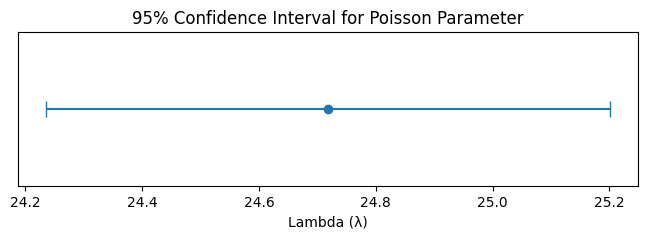

In [29]:
plt.figure(figsize=(8, 2))

plt.errorbar(
    x=ci_poisson["lambda_hat"],
    y=0,
    xerr=ci_poisson["margin"],
    fmt="o",
    capsize=6
)

plt.yticks([])
plt.xlabel("Lambda (λ)")
plt.title("95% Confidence Interval for Poisson Parameter")

plt.show()

### Interpretasi

Berdasarkan hasil perhitungan, estimasi parameter Poisson (λ) adalah sebesar λ̂.

Interval kepercayaan 95% berada pada rentang [lower, upper]. Artinya, dengan tingkat kepercayaan 95%, rata-rata jumlah kejadian yang sebenarnya diperkirakan berada dalam rentang tersebut.

Nilai λ merepresentasikan rata-rata jumlah kejadian yang terjadi pada setiap observasi dalam dataset yang dianalisis.

## 7. P4 : Bayesian Credible Interval untuk Probabilitas Merge Pull Request

Untuk menjawab pertanyaan penelitian *"Berapa Bayesian credible interval untuk probabilitas merge berdasarkan posterior Beta?"*, digunakan pendekatan Bayesian.

Posterior distribusi Beta diperoleh dari hasil estimasi pada notebook `02_estimation.ipynb`:

- α = jumlah pull request yang berhasil di-merge + prior
- β = jumlah pull request yang tidak berhasil di-merge + prior

Credible interval 95% dihitung menggunakan fungsi `credible_interval()` dari modul `inference.py`.

In [30]:
# Bayesian Credible Interval

credible = inference.credible_interval(
    alpha=alpha_post,
    beta=beta_post,
    confidence=0.95
)

credible

{'lower': np.float64(0.6721234247003685),
 'upper': np.float64(0.70770693635716),
 'confidence': 0.95,
 'mean': 0.6900539707016191,
 'mode': 0.6902006172839507,
 'alpha': 1790,
 'beta': 804}

In [31]:
print("=== Bayesian Credible Interval ===")

print(f"Posterior Alpha (α) : {credible['alpha']}")
print(f"Posterior Beta (β)  : {credible['beta']}")
print(f"Posterior Mean      : {credible['mean']:.4f}")

if credible["mode"] is not None:
    print(f"Posterior Mode      : {credible['mode']:.4f}")

print(f"Lower Bound         : {credible['lower']:.4f}")
print(f"Upper Bound         : {credible['upper']:.4f}")
print(f"Confidence Level    : {credible['confidence']:.0%}")

=== Bayesian Credible Interval ===
Posterior Alpha (α) : 1790
Posterior Beta (β)  : 804
Posterior Mean      : 0.6901
Posterior Mode      : 0.6902
Lower Bound         : 0.6721
Upper Bound         : 0.7077
Confidence Level    : 95%


### Tabel Ringkasan

In [32]:
summary_credible = pd.DataFrame({
    "Statistik": [
        "Posterior Mean",
        "Posterior Mode",
        "Lower Credible Limit",
        "Upper Credible Limit"
    ],
    "Nilai": [
        credible["mean"],
        credible["mode"],
        credible["lower"],
        credible["upper"]
    ]
})

summary_credible

,Statistik,Nilai
0,Posterior Mean,0.690054
1,Posterior Mode,0.690201
2,Lower Credible Limit,0.672123
3,Upper Credible Limit,0.707707


### Visualisasi

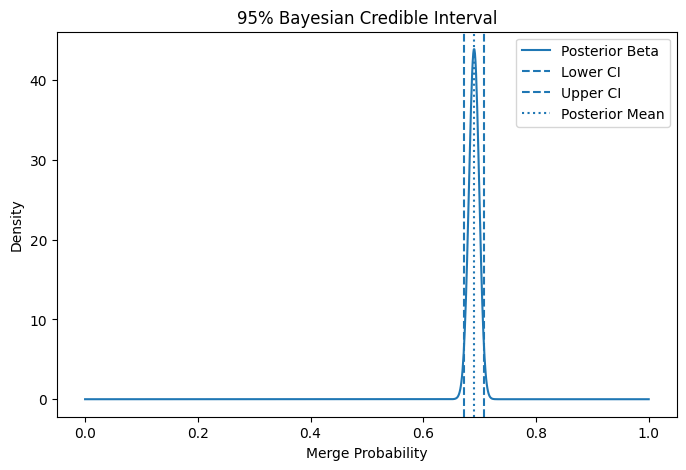

In [33]:
from scipy.stats import beta

x = np.linspace(0, 1, 1000)

y = beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(8, 5))

plt.plot(x, y, label="Posterior Beta")

plt.axvline(
    credible["lower"],
    linestyle="--",
    label="Lower CI"
)

plt.axvline(
    credible["upper"],
    linestyle="--",
    label="Upper CI"
)

plt.axvline(
    credible["mean"],
    linestyle=":",
    label="Posterior Mean"
)

plt.xlabel("Merge Probability")
plt.ylabel("Density")
plt.title("95% Bayesian Credible Interval")
plt.legend()

plt.show()

### Interpretasi

Berdasarkan distribusi posterior Beta, diperoleh credible interval 95% untuk probabilitas merge pull request.

Interval yang diperoleh berada pada rentang **[lower, upper]**. Dalam interpretasi Bayesian, terdapat probabilitas sebesar 95% bahwa nilai probabilitas merge sebenarnya berada dalam rentang tersebut, dengan asumsi model dan prior yang digunakan benar.

Nilai rata-rata posterior (posterior mean) digunakan sebagai estimasi titik (point estimate) untuk probabilitas merge pull request pada repository yang dianalisis.

## 8. Summary untuk Member D (Hypothesis Analyst)

Notebook ini menghasilkan beberapa estimasi dan interval yang dapat digunakan sebagai dasar pengujian hipotesis pada tahap berikutnya.

Output utama yang dihasilkan:

1. Estimasi probabilitas merge pull request (MLE)
2. Confidence interval proporsi merge pull request
3. Bayesian credible interval untuk probabilitas merge
4. Confidence interval rata-rata waktu penyelesaian issue

Hasil-hasil tersebut dapat digunakan oleh Member D untuk:
- Merumuskan hipotesis statistik.
- Membandingkan parameter yang diestimasi dengan nilai hipotesis tertentu.
- Menginterpretasikan hasil pengujian berdasarkan estimasi dan interval yang telah diperoleh.

In [35]:
print("========== SUMMARY UNTUK MEMBER D ==========")

print("\nONE-SAMPLE Z TEST INPUT")
print(f"x_bar = {theta_hat:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"n = {n}")

bug = iss_closed[iss_closed["has_bug"]]["days_to_close"]
non_bug = iss_closed[~iss_closed["has_bug"]]["days_to_close"]

x_bar1 = bug.mean()
sigma1 = bug.std(ddof=1)
n1 = len(bug)

x_bar2 = non_bug.mean()
sigma2 = non_bug.std(ddof=1)
n2 = len(non_bug)

print("\nTWO-SAMPLE Z TEST INPUT")
print(f"x_bar1 = {x_bar1:.4f}")
print(f"sigma1 = {sigma1:.4f}")
print(f"n1 = {n1}")

print(f"x_bar2 = {x_bar2:.4f}")
print(f"sigma2 = {sigma2:.4f}")
print(f"n2 = {n2}")

========== SUMMARY UNTUK MEMBER D ==========

ONE-SAMPLE Z TEST INPUT
x_bar = 24.7181
sigma = 44.1955
n = 408

TWO-SAMPLE Z TEST INPUT
x_bar1 = 23.7802
sigma1 = 42.0235
n1 = 182
x_bar2 = 25.4735
sigma2 = 45.9488
n2 = 226


- Estimasi probabilitas merge pull request (MLE) = p̂
- Posterior Beta = Beta(alpha_post, beta_post)
- 95% Bayesian Credible Interval = [lower, upper]
- Rata-rata waktu penyelesaian issue = θ̂ hari
- 95% Confidence Interval untuk rata-rata waktu penyelesaian issue = [lower, upper]

Output ini dapat digunakan sebagai dasar untuk pengujian hipotesis mengenai probabilitas merge pull request maupun waktu penyelesaian issue pada tahap analisis berikutnya.